<a href="https://colab.research.google.com/github/orca3/llm-model-serving/blob/main/ch07/SpecDecode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Sun Oct 12 16:08:29 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   36C    P0             55W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
!uv pip install vllm==0.11.0 torch

Using Python 3.12.11 environment at: /usr
Resolved 141 packages in 851ms
Prepared 39 packages in 8.08s
Uninstalled 5 packages in 89ms
Installed 39 packages in 67ms
 + astor==0.8.1
 + blake3==1.0.7
 + cbor2==5.7.0
 - click==8.3.0
 + click==8.2.1
 + compressed-tensors==0.11.0
 + depyf==0.19.0
 + diskcache==5.6.3
 + dnspython==2.8.0
 + email-validator==2.3.0
 + fastapi-cli==0.0.13
 + fastapi-cloud-cli==0.3.1
 + gguf==0.17.1
 + httptools==0.7.1
 + interegular==0.3.3
 - lark==1.3.0
 + lark==1.2.2
 + llguidance==0.7.30
 - llvmlite==0.43.0
 + llvmlite==0.44.0
 + lm-format-enforcer==0.11.3
 + mistral-common==1.8.5
 + msgspec==0.19.0
 + ninja==1.13.0
 - numba==0.60.0
 + numba==0.61.2
 + openai-harmony==0.0.4
 + outlines-core==0.2.11
 + partial-json-parser==0.2.1.1.post6
 + prometheus-fastapi-instrumentator==7.1.0
 + pybase64==1.4.2
 + pycountry==24.6.1
 + pydantic-extra-types==2.10.6
 + ray==2.50.0
 + rich-toolkit==0.15.1
 + rignore==0.7.0
 + setproctitle==1.3.7
 - setuptools==75.2.0
 + setupto

In [ ]:
import torch

In [ ]:
import vllm
from importlib.metadata import version
print(version("vllm"))
print(version("torch"))
print(version("numpy"))

0.11.0
2.8.0+cu126
2.0.2


In [ ]:
!nvidia-smi

Sun Oct 12 16:08:48 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   36C    P0             55W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
from openai import OpenAI


# Modify OpenAI's API key and API base to use vLLM's API server.
openai_api_key = "EMPTY"
openai_api_base = "http://localhost:8000/v1"
client = OpenAI(
    api_key=openai_api_key,
    base_url=openai_api_base,
)
model_id="Qwen/Qwen3-32B"

def run_vllm_bench_spec(
    *,
    base_url: str = "http://localhost:8000",
    model: str = "Qwen/Qwen3-32B",
    num_prompts: int = 16,
    spec_bench_output_len: int = 512,
    spec_bench_category: str | None = None,
    dataset_path: str = "Spec-Bench/data/spec_bench/question.jsonl",
    max_concurrency: int = 1,
    request_rate: float | None = None,
    burstiness: float | None = None,
    seed: int | None = None,
    result_filename: str = "spec_bench_decode.json",
    save_result: bool = True,
    append_result: bool = True,
):
    cmd_parts = [
        "vllm", "bench", "serve",
        "--backend", "vllm",
        "--base-url", base_url,
        "--endpoint", "/v1/completions",
        "--dataset-name", "spec_bench",
        "--num-prompts", str(num_prompts),
        "--model", model,
        "--max-concurrency", str(max_concurrency),
        "--spec-bench-output-len", str(spec_bench_output_len),
    ]

    if dataset_path is None:
        raise ValueError("Spec Bench needs --dataset-path pointing to the Spec-Bench file")

    cmd_parts += ["--dataset-path", dataset_path]

    if spec_bench_category:
        cmd_parts += ["--spec-bench-category", spec_bench_category]
    if request_rate is not None:
        cmd_parts += ["--request-rate", str(request_rate)]
    if burstiness is not None:
        cmd_parts += ["--burstiness", str(burstiness)]
    if seed is not None:
        cmd_parts += ["--seed", str(seed)]
    if save_result:
        cmd_parts.append("--save-result")
    if append_result:
        cmd_parts.append("--append-result")
    if result_filename:
        cmd_parts += ["--result-filename", result_filename]

    print("Running command:\n", " ".join(cmd_parts))

    import subprocess, shlex
    process = subprocess.Popen(
        cmd_parts,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    try:
        assert process.stdout is not None
        for line in process.stdout:
            print(line, end="")
    except KeyboardInterrupt:
        print("Interrupted by user, terminating benchmark...")
        process.terminate()
    process.wait()
    print(f"\nBenchmark finished with exit code {process.returncode}")
    return process.returncode


In [ ]:
!git clone https://github.com/hemingkx/Spec-Bench.git

Cloning into 'Spec-Bench'...
remote: Enumerating objects: 464, done.
remote: Counting objects: 100% (204/204), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 464 (delta 169), reused 135 (delta 135), pack-reused 260 (from 1)
Receiving objects: 100% (464/464), 4.00 MiB | 8.06 MiB/s, done.
Resolving deltas: 100% (262/262), done.


In [ ]:
#!pkill -f "vllm serve"

# Vanilla vLLM

In [ ]:
%%bash
nohup vllm serve Qwen/Qwen3-32B \
  --disable-log-requests \
  --max-model-len 2048 \
  --gpu-memory-utilization 0.95 \
  > vllm.log 2>&1 &

In [ ]:
import time
import requests
from collections import deque

def tail_log(filename, n=2):
    """Read and print the last n lines of a log file."""
    try:
        with open(filename, 'r') as f:
            last_lines = deque(f, maxlen=n)
        print(f"\n📜 Last {n} lines from {filename}:")
        for line in last_lines:
            print(line.rstrip())
    except FileNotFoundError:
        print(f"⚠️ Log file {filename} not found.")
    except Exception as e:
        print(f"⚠️ Error reading log file: {e}")

def check_vllm_status():
    max_retries = 100
    wait_time = 10  # seconds

    print("⏳ Waiting for vLLM server to become healthy...")

    for i in range(max_retries):
        try:
            r = requests.get("http://127.0.0.1:8000/health")
            if r.ok:
                print("✅ vLLM server is healthy and ready!")
                tail_log("vllm.log", n=2)
                break
        except Exception:
            print(f"Attempt {i+1}: Not ready yet...")

        # Always print the last two lines of the log each iteration
        tail_log("vllm.log", n=2)

        time.sleep(wait_time)
    else:
        print("❌ Timed out waiting for vLLM server to start.")
        tail_log("vllm.log", n=2)

check_vllm_status()
run_vllm_bench_spec(max_concurrency = 1)
run_vllm_bench_spec(max_concurrency = 16)

⏳ Waiting for vLLM server to become healthy...
Attempt 1: Not ready yet...

📜 Last 2 lines from vllm.log:
Attempt 2: Not ready yet...

📜 Last 2 lines from vllm.log:
2025-10-12 16:08:57.954905: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Attempt 3: Not ready yet...

📜 Last 2 lines from vllm.log:
(APIServer pid=2309) INFO 10-12 16:09:09 [api_server.py:1839] vLLM API server version 0.11.0
(APIServer pid=2309) INFO 10-12 16:09:09 [utils.py:233] non-default args: {'model_tag': 'Qwen/Qwen3-32B', 'model': 'Qwen/Qwen3-32B', 'max_model_len': 2048, 'gpu_memory_utilization': 0.95}
Attempt 4: Not ready yet...

📜 Last 2 lines from vllm.log:
(APIServer pid=2309) INFO 10-12 16:09:09 [api_server.py:1839] vLLM API server version 0.11.0
(APIServer 

0

# n-gram

In [ ]:
!pkill -f "vllm serve"
time.sleep(15)

In [ ]:
%%bash
nohup vllm serve Qwen/Qwen3-32B \
  --speculative-config '{
    "method": "ngram",
    "num_speculative_tokens": 6,
    "prompt_lookup_min": 4,
    "prompt_lookup_max": 6
}' \
  --disable-log-requests \
  --max-model-len 2048 \
  --gpu-memory-utilization 0.95 \
  > vllm.log 2>&1 &

In [ ]:
check_vllm_status()

run_vllm_bench_spec(max_concurrency = 1)
run_vllm_bench_spec(max_concurrency = 16)

⏳ Waiting for vLLM server to become healthy...
Attempt 1: Not ready yet...

📜 Last 2 lines from vllm.log:
Attempt 2: Not ready yet...

📜 Last 2 lines from vllm.log:
2025-10-12 16:26:19.440487: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Attempt 3: Not ready yet...

📜 Last 2 lines from vllm.log:
(APIServer pid=7579) INFO 10-12 16:26:29 [model.py:1510] Using max model len 2048
(APIServer pid=7579) INFO 10-12 16:26:30 [scheduler.py:205] Chunked prefill is enabled with max_num_batched_tokens=2048.
Attempt 4: Not ready yet...

📜 Last 2 lines from vllm.log:
(EngineCore_DP0 pid=7694) INFO 10-12 16:26:44 [core.py:644] Waiting for init message from front-end.
(EngineCore_DP0 pid=7694) INFO 10-12 16:26:44 [core.py:77] Initializing a V1 LLM 

0

# Improved n-gram

In [ ]:
!pkill -f "vllm serve"
time.sleep(15)

In [ ]:
%%bash
nohup vllm serve Qwen/Qwen3-32B \
  --speculative-config '{
    "method": "ngram",
    "num_speculative_tokens": 4,
    "prompt_lookup_min": 2,
    "prompt_lookup_max": 128
}' \
  --disable-log-requests \
  --max-model-len 2048 \
  --gpu-memory-utilization 0.95 \
  > vllm.log 2>&1 &

In [ ]:
check_vllm_status()

run_vllm_bench_spec(max_concurrency = 1)
run_vllm_bench_spec(max_concurrency = 16)

⏳ Waiting for vLLM server to become healthy...
Attempt 1: Not ready yet...

📜 Last 2 lines from vllm.log:
Attempt 2: Not ready yet...

📜 Last 2 lines from vllm.log:
2025-10-12 16:37:29.587450: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Attempt 3: Not ready yet...

📜 Last 2 lines from vllm.log:
(APIServer pid=11168) INFO 10-12 16:37:39 [model.py:1510] Using max model len 2048
(APIServer pid=11168) INFO 10-12 16:37:40 [scheduler.py:205] Chunked prefill is enabled with max_num_batched_tokens=2048.
Attempt 4: Not ready yet...

📜 Last 2 lines from vllm.log:
(EngineCore_DP0 pid=11289) INFO 10-12 16:37:54 [core.py:644] Waiting for init message from front-end.
(EngineCore_DP0 pid=11289) INFO 10-12 16:37:54 [core.py:77] Initializing a V1 

0

# Eagle3

In [ ]:
!pkill -f "vllm serve"
time.sleep(15)

In [ ]:
%%bash
nohup vllm serve Qwen/Qwen3-32B \
  --speculative-config '{
    "method": "eagle3",
    "model": "RedHatAI/Qwen3-32B-speculator.eagle3",
    "num_speculative_tokens": 3
  }' \
  --disable-log-requests \
  --max-model-len 2048 \
  --gpu-memory-utilization 0.95 \
  > vllm.log 2>&1 &


In [ ]:
check_vllm_status()

run_vllm_bench_spec(max_concurrency = 1)
run_vllm_bench_spec(max_concurrency = 16)

⏳ Waiting for vLLM server to become healthy...
✅ vLLM server is healthy and ready!

📜 Last 2 lines from vllm.log:
(APIServer pid=13564) INFO 10-12 16:54:25 [loggers.py:127] Engine 000: Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 0.0 tokens/s, Running: 0 reqs, Waiting: 0 reqs, GPU KV cache usage: 0.0%, Prefix cache hit rate: 40.9%
(APIServer pid=13564) INFO:     127.0.0.1:49310 - "GET /health HTTP/1.1" 200 OK
Running command:
 vllm bench serve --backend vllm --base-url http://localhost:8000 --endpoint /v1/completions --dataset-name spec_bench --num-prompts 16 --model Qwen/Qwen3-32B --max-concurrency 1 --spec-bench-output-len 512 --dataset-path Spec-Bench/data/spec_bench/question.jsonl --save-result --append-result --result-filename spec_bench_decode.json
INFO 10-12 17:04:58 [__init__.py:216] Automatically detected platform cuda.
2025-10-12 17:04:59.939663: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical re

0

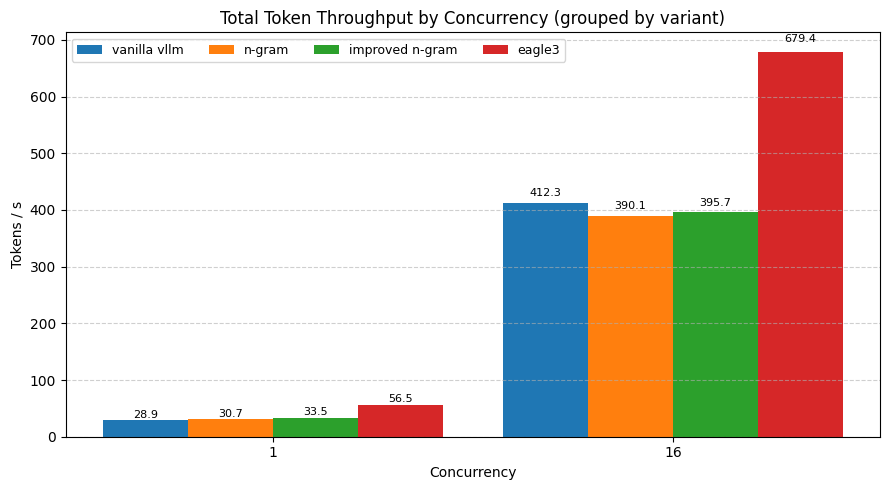

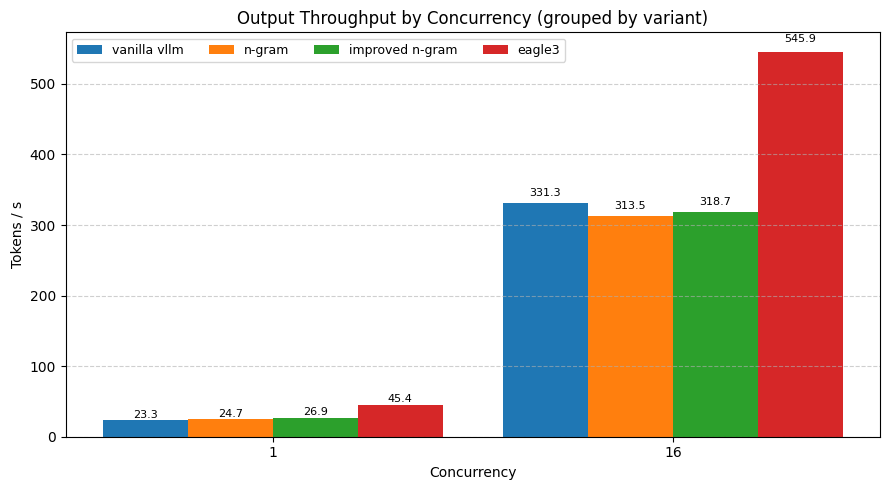

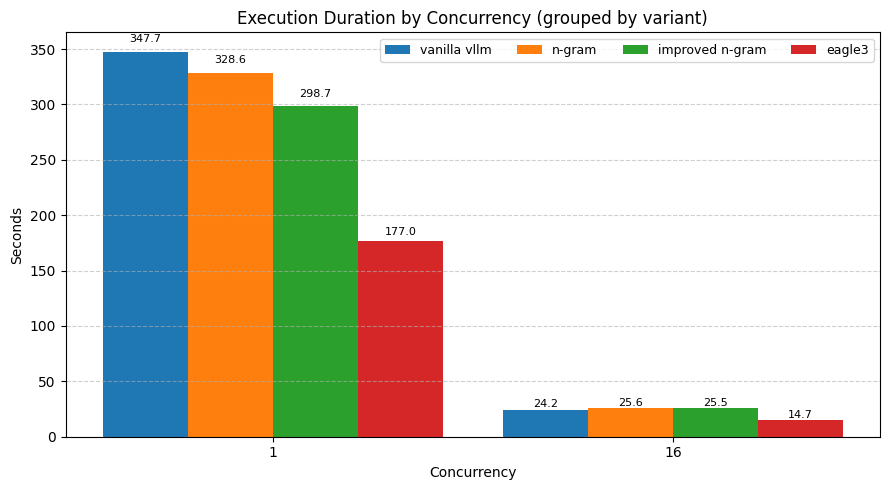

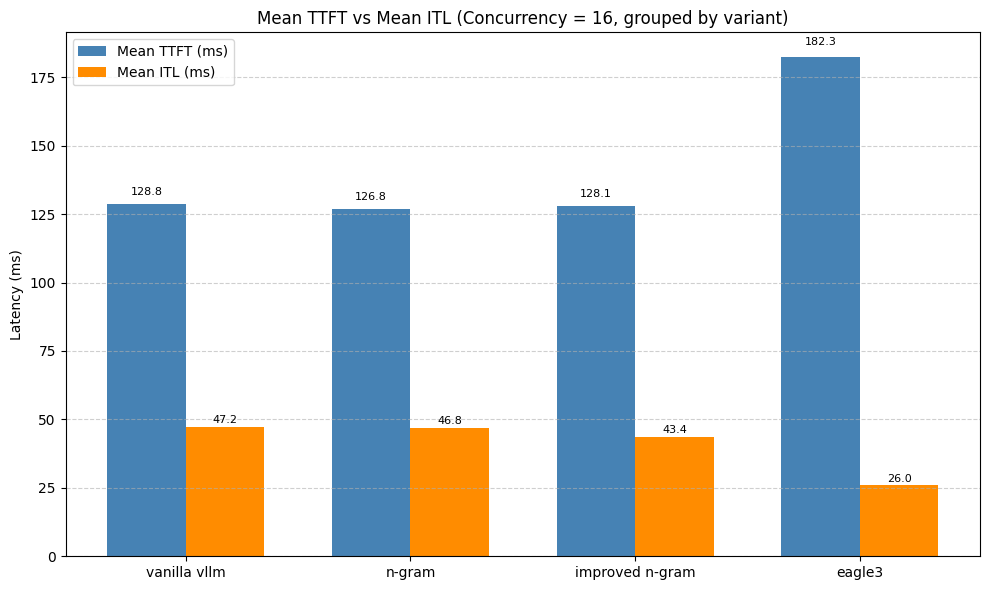

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ----- Load data -----
with open("spec_bench_decode.json", "r") as f:
    data = [json.loads(line) for line in f if line.strip()]

# ----- Variants & assumed ordering -----
# Assumes file order: [v0@c1, v0@c16, v1@c1, v1@c16, v2@c1, v2@c16, v3@c1, v3@c16]
variant_labels = ['vanilla vllm', 'n-gram', 'improved n-gram', 'eagle3']

if len(data) != 2 * len(variant_labels):
    raise ValueError(f"Expected {2*len(variant_labels)} rows, got {len(data)}")

# ----- Detect concurrencies -----
concs = sorted({d["max_concurrency"] for d in data})
if len(concs) != 2:
    raise ValueError(f"Expected exactly 2 concurrencies in data, found {concs}")
c1, c2 = concs  # e.g., 1 and 16

# ----- Build per-variant records for each concurrency -----
# records[(variant_idx, concurrency)] = dict
records = {}
for i, d in enumerate(data):
    v_idx = i // 2
    records[(v_idx, d["max_concurrency"])] = d

def metric_by_concurrency(key, scale=1.0):
    """Return arrays shaped (num_concurrencies=2, num_variants)."""
    vals_c1 = [records[(i, c1)][key] / scale for i in range(len(variant_labels))]
    vals_c2 = [records[(i, c2)][key] / scale for i in range(len(variant_labels))]
    return np.array([vals_c1, vals_c2])  # shape (2, V)

# ----- Extract metrics -----
total_tput = metric_by_concurrency("total_token_throughput")        # (2, V)
output_tput = metric_by_concurrency("output_throughput")            # (2, V)
durations   = metric_by_concurrency("duration")                     # (2, V)
mean_ttft   = metric_by_concurrency("mean_ttft_ms")                 # (2, V)
mean_tpot   = metric_by_concurrency("mean_tpot_ms")                 # (2, V)

# ----- Plot helper: x-axis = concurrencies, bars grouped by variant -----
def grouped_bars_by_variant(ax, values, title, ylabel, variants, concurrencies):
    """
    values: shape (num_concurrencies, num_variants)
    x-axis: concurrencies
    inside each concurrency bucket: one bar per variant
    """
    num_conc, num_vars = values.shape
    assert num_conc == 2, "This helper expects exactly 2 concurrencies."
    x = np.arange(num_conc)  # [0,1] -> [c1,c2]
    group_width = 0.85
    bar_width = group_width / num_vars
    # center the bars around each x
    offsets = (np.arange(num_vars) - (num_vars - 1) / 2.0) * bar_width

    for v_idx in range(num_vars):
        ax.bar(x + offsets[v_idx], values[:, v_idx], width=bar_width, label=variants[v_idx])

        # value labels
        for xi, val in zip(x + offsets[v_idx], values[:, v_idx]):
            ax.text(xi, val * 1.02, f"{val:.1f}", ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in concurrencies])
    ax.set_xlabel("Concurrency")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(ncols=min(len(variants), 4), fontsize=9)

# =====================================================
# Plot 1: Total Token Throughput (tokens/s)
# =====================================================
fig, ax = plt.subplots(figsize=(9, 5))
grouped_bars_by_variant(
    ax,
    total_tput,
    title="Total Token Throughput by Concurrency (grouped by variant)",
    ylabel="Tokens / s",
    variants=variant_labels,
    concurrencies=[c1, c2],
)
plt.tight_layout()
plt.show()

# =====================================================
# Plot 2: Output Throughput (tokens/s)
# =====================================================
fig, ax = plt.subplots(figsize=(9, 5))
grouped_bars_by_variant(
    ax,
    output_tput,
    title="Output Throughput by Concurrency (grouped by variant)",
    ylabel="Tokens / s",
    variants=variant_labels,
    concurrencies=[c1, c2],
)
plt.tight_layout()
plt.show()

# =====================================================
# Plot 3: Duration (s)
# =====================================================
fig, ax = plt.subplots(figsize=(9, 5))
grouped_bars_by_variant(
    ax,
    durations,
    title="Execution Duration by Concurrency (grouped by variant)",
    ylabel="Seconds",
    variants=variant_labels,
    concurrencies=[c1, c2],
)
plt.tight_layout()
plt.show()

# =====================================================
# Plot 4: Latency (Mean TTFT vs Mean TPOT) — concurrency = 16
# =====================================================
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(variant_labels))
bar_width = 0.35

# Use index [1, :] for concurrency = 16
ttft_vals = mean_ttft[1, :]
tpot_vals = mean_tpot[1, :]

plt.bar(x - bar_width/2, ttft_vals, width=bar_width, label='Mean TTFT (ms)', color='steelblue')
plt.bar(x + bar_width/2, tpot_vals, width=bar_width, label='Mean ITL (ms)', color='darkorange')

# Add numeric labels
for pos, val in zip(x - bar_width/2, ttft_vals):
    plt.text(pos, val * 1.02, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
for pos, val in zip(x + bar_width/2, tpot_vals):
    plt.text(pos, val * 1.02, f"{val:.1f}", ha='center', va='bottom', fontsize=8)

plt.xticks(x, variant_labels)
plt.ylabel("Latency (ms)")
plt.title("Mean TTFT vs Mean ITL (Concurrency = 16, grouped by variant)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
len(data)

6